In [4]:
!pip install groq -q
print("Groq installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.5 MB/s eta 0:00:00
Groq installed successfully


In [5]:
import sqlite3
import pandas as pd
import os
from groq import Groq
import re
print("All libraries imported successfully")

All libraries imported successfully


In [6]:
import os
os.environ["GROQ_API_KEY"] = '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'
client = Groq(api_key=os.environ["GROQ_API_KEY"])
MODEL = "llama-3.1-8b-instant"
print("Using Model:", MODEL)

Using Model: llama-3.1-8b-instant


In [7]:
df = pd.read_csv('/content/drive/MyDrive/15 days intern dataset/student_performance.csv')
print("=== Data Loaded Successfully ===")

=== Data Loaded Successfully ===


In [8]:
conn = sqlite3.connect('college.db')
df.to_sql('students', conn, if_exists = 'replace', index = False)
test_df = pd.read_sql_query("select name,age from students", conn)
print("=== Test Dataframe ===")
print(test_df)



=== Test Dataframe ===
              name  age
0     Aarav Sharma   19
1      Priya Patel   20
2      Rohit Verma   19
3      Sneha Reddy   20
4       Arjun Nair   19
5      Meera Joshi   20
6      Kiran Kumar   21
7      Divya Singh   19
8     Rahul Mishra   20
9       Ananya Das   19
10     Vikram Iyer   20
11     Pooja Gupta   19
12      Suresh Rao   21
13   Kavya Nambiar   20
14     Ajay Tiwari   19
15    Ritu Agarwal   20
16    Manoj Pandey   21
17  Swati Kulkarni   19
18  Deepak Chauhan   20
19    Nisha Kapoor   19
20   Harish Pillai   20
21     Tanvi Mehta   19
22    Sanjay Dubey   21
23   Preeti Saxena   20
24       Amit Bose   19
25      Rekha Nair   20
26   Gaurav Shukla   21
27   Sunita Pillai   19
28      Nitin Jain   20
29  Akanksha Yadav   19


In [9]:
conn = sqlite3.connect('college.db')
df.to_sql('students', conn, if_exists = 'replace', index = False)
test_df = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM STUDENTS", conn)
print("=== Test Dataframe ===")
print(test_df)



=== Test Dataframe ===
   total_rows
0          30


In [10]:
def get_schema(conn, table_name = "students"):
  """
  this is the description
  """

  cursor = conn.cursor()
  cursor.execute(f"PRAGMA table_info({table_name})")
  columns = cursor.fetchall()
  schema_lines = ["Table:", table_name]
  schema_lines.append("Columns:")

  for col in columns:
    schema_lines.append(f" - {col[1]} ({col[2]})")

  cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")

  sammple_rows = cursor.fetchall()
  schema_lines.append("Sample Rows (first 3):")

  for row in sammple_rows:
    schema_lines.append(f" - {row}")

  return "\n".join(schema_lines)

schema = get_schema(conn)
print(schema)

Table:
students
Columns:
 - student_id (INTEGER)
 - name (TEXT)
 - age (INTEGER)
 - gender (TEXT)
 - department (TEXT)
 - semester (INTEGER)
 - math_score (INTEGER)
 - science_score (INTEGER)
 - english_score (INTEGER)
 - programming_score (INTEGER)
 - attendance_percentage (INTEGER)
 - city (TEXT)
 - admission_year (INTEGER)
Sample Rows (first 3):
 - (1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
 - (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
 - (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [11]:
def generate_sql(user_question,schema_text,client,model):
  """
  this is the description function for generating sql queries

  """

  system_prompt = f"""
You are an expert SQLite SQL assistant.

Generate only valid SQLite SQL queries.

Database Rules:
1. Use only the table named: students
2. Do not invent table names
3. Use only columns from the schema
4. Return only SQL query
5. No explanations
6. No markdown

Database Schema:
{schema_text}
"""

  response  = client.chat.completions.create(
    model = model,
    messages = [
      {"role": "system","content": system_prompt},
      {"role": "user","content": user_question}
    ],
    temperature = 0.0
  )

  sql_query = response.choices[0].message.content.strip()
  return sql_query

question = input("Enter the Question")
print("Question:", question)
print("Generating sql ...")

sql = generate_sql(question,schema,client,MODEL)
print("Generated SQL:", sql)


Enter the Questionfemale students with age
Question: female students with age
Generating sql ...
Generated SQL: SELECT name, age FROM students WHERE gender = 'Female'


In [12]:
def execute_sql(sql_query,conn):
    """
    Clean and execute SQL query on SQLite database.

    Parameters:
    sql_query : str
        SQL query generated by LLM

    conn : sqlite3.Connection
        SQLite database connection object

    Returns:
    result_df : pandas.DataFrame
        Query execution result
    """

    clean_sql = sql_query.strip()
    clean_sql = re.sub(r'```\S*', '', clean_sql)
    clean_sql = clean_sql.strip()

    try:
        result_df = pd.read_sql_query(clean_sql, conn)
        return result_df, None
    except Exception as e:
      return None, str(e)

print("Exceuting SQL:", sql)
result , error = execute_sql(sql,conn)

if error:
  print("Error:", error)
else:
  print("Query Returned:", len(result))
  print(result)

Exceuting SQL: SELECT name, age FROM students WHERE gender = 'Female'
Query Returned: 15
              name  age
0      Priya Patel   20
1      Sneha Reddy   20
2      Meera Joshi   20
3      Divya Singh   19
4       Ananya Das   19
5      Pooja Gupta   19
6    Kavya Nambiar   20
7     Ritu Agarwal   20
8   Swati Kulkarni   19
9     Nisha Kapoor   19
10     Tanvi Mehta   19
11   Preeti Saxena   20
12      Rekha Nair   20
13   Sunita Pillai   19
14  Akanksha Yadav   19


Fetching data for plot with SQL: SELECT department, programming_score FROM students


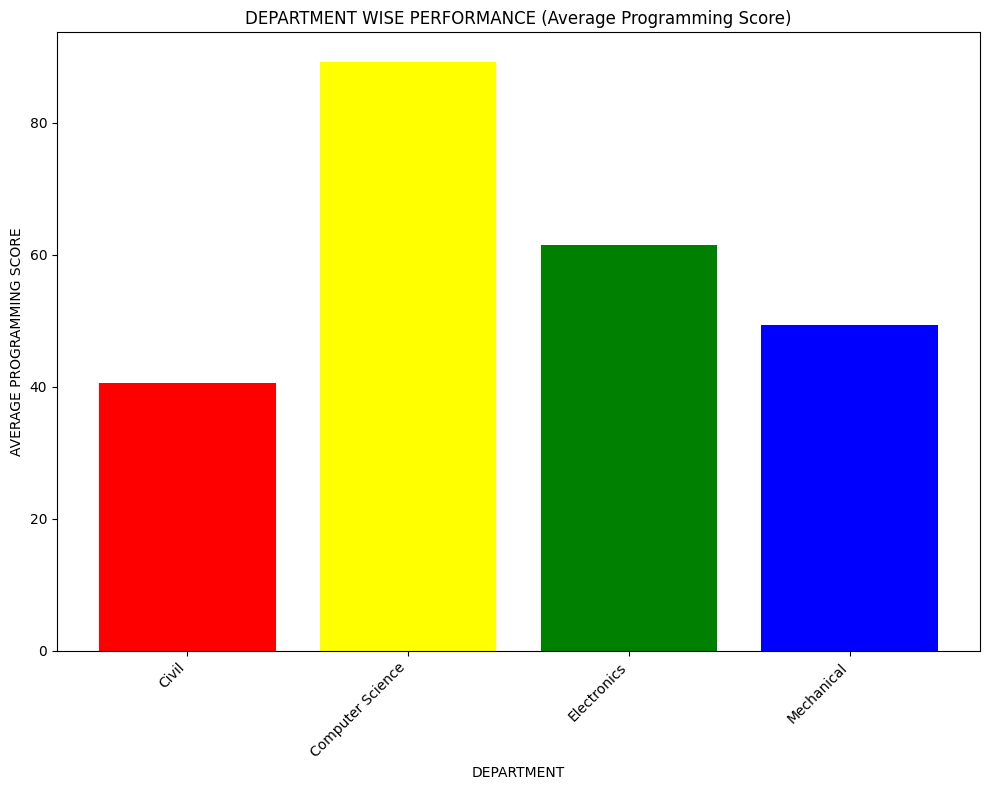

In [13]:
import matplotlib.pyplot as plt

sql_for_plot = "SELECT department, programming_score FROM students"
print(f"Fetching data for plot with SQL: {sql_for_plot}")

# Re-using the execute_sql function from a previous cell
plot_data, error_plot = execute_sql(sql_for_plot, conn)

if error_plot:
  print(f"Error fetching data for plot: {error_plot}")
else:
  # Aggregate programming scores by department (e.g., mean) for the bar chart
  department_scores = plot_data.groupby("department")["programming_score"].mean().reset_index()

  fig , ax = plt.subplots(figsize = (10,8))
  plt.xlabel("DEPARTMENT")
  plt.ylabel("AVERAGE PROGRAMMING SCORE") # Changed label to reflect aggregation
  plt.title("DEPARTMENT WISE PERFORMANCE (Average Programming Score)") # Changed title to reflect aggregation
  plt.bar(department_scores["department"], department_scores["programming_score"],color=['red','yellow','green','blue'])
  plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
  plt.tight_layout() # Adjust layout to prevent labels from overlapping
  plt.show()

In [14]:
def test_to_sql_agent(user_question,conn,client,model,verbose=True):
  """THIS IS THE DESCRIPTION FOR THE FUNCTION TO TEST THE AGENT
     IT TAKE THE USER QUESTION AS A TEXT AND RETURN THE DATABASE FORMAT OF RESULT
     1. GET THE DATABASE SCHEMA
     2. GENERATE THE SQL USING GROQ LLM
     3. EXECUTE SQL ON THE DATABASE
     4. FORMAT AND RETURN RESULT
  """
  print("="*60)
  if verbose:
    print("\n[STEP 1] Reading the DataBase Schema ...")
  schema_text = get_schema(conn)

  if verbose:
    print("Schema Loaded Successfully...")
  if verbose:
    print("\n[STEP 2] Generating SQL query with GROQ LLM...")
  generated_sql = generate_sql(user_question,schema_text,client,model)
  if verbose:
    print(f"Generated SQL : \n {generated_sql}")
  if verbose:
    print("\n [STEP 3] Executing SQL on the database...")
  result_df,error = execute_sql(generated_sql,conn)
  if error:
    print(f"SQL Execution Error : {error}")
    return None,generated_sql
  if verbose:
    print(f"\n [STEP 4] Query returned {len(result_df)} row(s)")
    print("\nRESULTS : ")
    print("-"*40)
    print(result_df.to_string(index=False))
  print("="*40)
  return result_df,generated_sql
question = input("ENTER THE QUESTION : ")
result,sql_used = test_to_sql_agent(
    question,
    conn,
    client,
    MODEL
)

ENTER THE QUESTION : all male students with age

[STEP 1] Reading the DataBase Schema ...
Schema Loaded Successfully...

[STEP 2] Generating SQL query with GROQ LLM...
Generated SQL : 
 SELECT name, age FROM students WHERE gender = 'Male'

 [STEP 3] Executing SQL on the database...

 [STEP 4] Query returned 15 row(s)

RESULTS : 
----------------------------------------
          name  age
  Aarav Sharma   19
   Rohit Verma   19
    Arjun Nair   19
   Kiran Kumar   21
  Rahul Mishra   20
   Vikram Iyer   20
    Suresh Rao   21
   Ajay Tiwari   19
  Manoj Pandey   21
Deepak Chauhan   20
 Harish Pillai   20
  Sanjay Dubey   21
     Amit Bose   19
 Gaurav Shukla   21
    Nitin Jain   20


In [15]:
def dataframe_to_natural_language(user_question, result_df, client, model):
    """
    Convert DataFrame result into a natural language answer.
    """

    if result_df.empty:
        return "No records were found for your question."

    result_text = result_df.to_string(index=False)

    prompt = f"""
    User Question:
    {user_question}

    Query Result:
    {result_text}

    Provide a concise and accurate natural language answer based on the result.
    Do not mention SQL queries or database tables.
    """

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature = 0.0
    )

    return response.choices[0].message.content


def test_to_sql_agent(user_question, conn, client, model, verbose=True):
    """
    1. Get database schema
    2. Generate SQL using LLM
    3. Execute SQL
    4. Return DataFrame result
    5. Convert result to natural language
    """

    print("=" * 60)

    if verbose:
        print("\n[STEP 1] Reading the Database Schema...")
    schema_text = get_schema(conn)

    if verbose:
        print("Schema Loaded Successfully...")

    if verbose:
        print("\n[STEP 2] Generating SQL query with GROQ LLM...")
    generated_sql = generate_sql(
        user_question,
        schema_text,
        client,
        model
    )

    if verbose:
        print(f"Generated SQL:\n{generated_sql}")

    if verbose:
        print("\n[STEP 3] Executing SQL on the database...")

    result_df, error = execute_sql(generated_sql, conn)

    if error:
        print(f"SQL Execution Error: {error}")
        return None, generated_sql, None

    if verbose:
        print(f"\n[STEP 4] Query returned {len(result_df)} row(s)")
        print("\nRESULTS:")
        print("-" * 40)
        print(result_df.to_string(index=False))

    if verbose:
        print("\n[STEP 5] Generating Natural Language Answer...")

    nl_answer = dataframe_to_natural_language(
        user_question,
        result_df,
        client,
        model
    )

    print("\nNatural Language Answer:")
    print(nl_answer)

    print("=" * 60)

    return result_df, generated_sql, nl_answer


# Run the Agent
question = input("ENTER THE QUESTION: ")

result_df, sql_used, answer = test_to_sql_agent(
    question,
    conn,
    client,
    MODEL
)

print("\nGenerated SQL:")
print(sql_used)

print("\nFinal Answer:")
print(answer)


ENTER THE QUESTION: male students with total score

[STEP 1] Reading the Database Schema...
Schema Loaded Successfully...

[STEP 2] Generating SQL query with GROQ LLM...
Generated SQL:
SELECT SUM(math_score + science_score + english_score + programming_score) AS total_score FROM students WHERE gender = 'Male'

[STEP 3] Executing SQL on the database...

[STEP 4] Query returned 1 row(s)

RESULTS:
----------------------------------------
 total_score
        4210

[STEP 5] Generating Natural Language Answer...

Natural Language Answer:
The total score for male students is 4210.

Generated SQL:
SELECT SUM(math_score + science_score + english_score + programming_score) AS total_score FROM students WHERE gender = 'Male'

Final Answer:
The total score for male students is 4210.
